<a href="https://colab.research.google.com/github/helonayala/sysid/blob/main/phys_14_drone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Physics-based model

Nonlinear, physics-based **continuous-time state-space** model of the 1/4 drone, with state `x = [theta, theta_dot]` (angle, angular velocity).

From Euler-Lagrange (see the *1/4 drone Lagrangian* example) the rotary arm obeys `J*theta_ddot = -m g l * sin(theta) - b*theta_dot + tau_motor`. The motor is a propeller: thrust grows with the **square of the propeller speed**, and the command `u` is (approximately) proportional to that speed, so the motor torque is **proportional to `u^2`**. Lumping the constants gives the identifiable form

$$\ddot\theta = c_1\,\sin\theta + c_2\,u^2 + c_3\,\dot\theta$$

- `c1 sin(theta)` : gravity restoring torque / inertia
- `c2 u^2`        : propeller thrust / inertia (motor force ~ u^2)
- `c3 theta_dot`  : viscous friction / inertia (linear in velocity)

The three parameters are identified from data **two ways** — `scipy.optimize.least_squares` and a **Neural-ODE-style** PyTorch fit (`torchdiffeq` + Adam) — both minimizing the short-rollout simulation error, using the same train/test protocol as the NARX/NODE models.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.signal import savgol_filter
from scipy.optimize import least_squares

try:
    from torchdiffeq import odeint
except ImportError:
    !pip install -q torchdiffeq
    from torchdiffeq import odeint
try:
    from sysid import readData
except ImportError:
    !pip install -q git+https://github.com/helonayala/sysid.git
    from sysid import readData

torch.manual_seed(0); np.random.seed(0)
Ts = 0.05; L = 20; d2r = np.pi / 180.0


## Load and preprocess

Same selection as the other 1/4 drone models: slice 20-80 s, decimate by 5. The angle is converted to radians and the velocity is estimated with a Savitzky-Golay filter.

In [2]:
T_START, T_END, DECIMATION = 20.0, 80.0, 5
SG_WIN, SG_POLY = 11, 3

def load_processed(name):
    y, u, t, ref = readData('quarter_drone', name, return_ref=True)
    idx = np.where((t >= T_START) & (t <= T_END))[0]
    sl = slice(idx[0], idx[-1] + 1, DECIMATION)
    theta_deg = y[sl].astype(float)
    th = theta_deg * d2r
    return dict(u=u[sl].astype(float), th=th, theta_deg=theta_deg,
                thd=savgol_filter(th, SG_WIN, SG_POLY, deriv=1, delta=Ts),
                t=t[sl].astype(float))

data = {n: load_processed(n) for n in ['multiseno', 'degraus', 'swept_sine']}


## Semi-static check: motor force ~ u^2

On the slow (semi-static) experiment, holding a larger angle needs more motor force. Plotting `u` vs angle gives a parabola, and `u^2` is (nearly) linear in `sin(theta)` — i.e. the propeller thrust `~ u^2` balances the gravity torque `~ sin(theta)`.

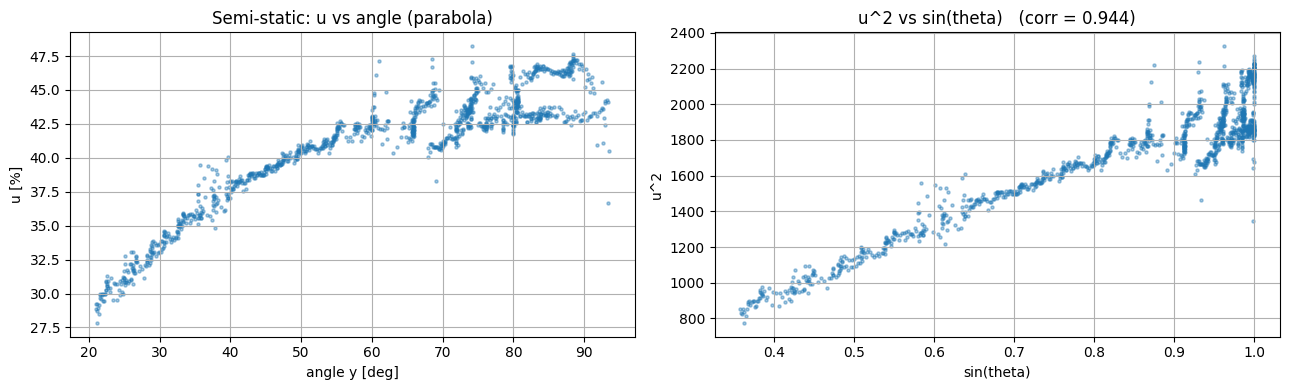

In [3]:
ss = load_processed('semi_estatica')
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.scatter(ss['theta_deg'], ss['u'], s=5, alpha=0.4)
a1.set_xlabel('angle y [deg]'); a1.set_ylabel('u [%]')
a1.set_title('Semi-static: u vs angle (parabola)'); a1.grid(True)
a2.scatter(np.sin(ss['th']), ss['u'] ** 2, s=5, alpha=0.4)
a2.set_xlabel('sin(theta)'); a2.set_ylabel('u^2')
r = np.corrcoef(ss['u'] ** 2, np.sin(ss['th']))[0, 1]
a2.set_title(f'u^2 vs sin(theta)   (corr = {r:.3f})'); a2.grid(True)
plt.tight_layout(); plt.show()


## Train / test split and rollout windows

**Interleaved 60/40 split**: every dataset is cut into 5 equal blocks (20% each) assigned `train, test, train, test, train` (3 train = 60%, 2 test = 40%). Rollout windows of length 20 are taken from the **train blocks of all datasets**.

In [4]:
def block_edges(N, n=5):
    return [int(round(i * N / n)) for i in range(n + 1)]

def train_test_blocks(N):
    e = block_edges(N)
    return [(e[b], e[b+1]) for b in (0, 2, 4)], [(e[b], e[b+1]) for b in (1, 3)]

# boolean test mask per dataset (for evaluation)
test_mask = {}
for name, d in data.items():
    N = len(d['th']); _, te = train_test_blocks(N)
    m = np.zeros(N, bool)
    for a, b in te: m[a:b] = True
    test_mask[name] = m

def windows_from_block(d, a, b, L=L):
    th, thd, u = d['th'], d['thd'], d['u']
    o = [[], [], [], []]
    for i in range(a, b - L):
        o[0].append(th[i]); o[1].append(thd[i]); o[2].append(u[i:i+L]); o[3].append(th[i:i+L])
    return o

TH0, THD0, US, TG = [], [], [], []
for name, d in data.items():
    tr, _ = train_test_blocks(len(d['th']))
    for a, b in tr:
        o = windows_from_block(d, a, b)
        TH0 += o[0]; THD0 += o[1]; US += o[2]; TG += o[3]
TH0 = np.array(TH0); THD0 = np.array(THD0); US = np.array(US); TG = np.array(TG)
print(f'Training windows: {len(TH0)}  (train blocks of all datasets, L={L})')


Training windows: 1983  (train blocks of all datasets, L=20)


## Continuous model, integrator and equation-error initialization

`theta_ddot = c1 sin(theta) + c2 u^2 + c3 theta_dot`, integrated with fixed-step RK4 (ZOH input). The parameters are first initialized by linear least squares on the acceleration (equation error).

In [5]:
def accel(th, thd, u, p):
    return p[0] * np.sin(th) + p[1] * u ** 2 + p[2] * thd

def rk4_rollout(th0, thd0, useq, p):
    """Fixed-step RK4 with ZOH input. Vectorized over windows; returns theta(.,L)."""
    th = np.array(th0, float); thd = np.array(thd0, float); out = [np.array(th)]
    for k in range(useq.shape[-1] - 1):
        u = useq[..., k]
        f = lambda a, b: (b, accel(a, b, u, p))
        k1 = f(th, thd)
        k2 = f(th + Ts/2*k1[0], thd + Ts/2*k1[1])
        k3 = f(th + Ts/2*k2[0], thd + Ts/2*k2[1])
        k4 = f(th + Ts*k3[0], thd + Ts*k3[1])
        th = th + Ts/6*(k1[0]+2*k2[0]+2*k3[0]+k4[0])
        thd = thd + Ts/6*(k1[1]+2*k2[1]+2*k3[1]+k4[1])
        out.append(np.array(th))
    return np.stack(out, -1)

# equation-error LS init (from full signals; just an initial guess)
sa = np.concatenate([data[n]['th'] for n in data])
ua = np.concatenate([data[n]['u'] for n in data])
da = np.concatenate([data[n]['thd'] for n in data])
ddot = np.concatenate([savgol_filter(data[n]['th'], SG_WIN, SG_POLY, deriv=2, delta=Ts) for n in data])
p_init, *_ = np.linalg.lstsq(np.column_stack([np.sin(sa), ua ** 2, da]), ddot, rcond=None)
print('equation-error init [c1, c2, c3] =', np.round(p_init, 6))


equation-error init [c1, c2, c3] = [-5.118533e+00  2.562000e-03 -4.612970e-01]


## Version A - scipy.optimize.least_squares (simulation error)

Refine the parameters by minimizing the 20-sample rollout residuals (Levenberg-Marquardt), starting from the equation-error estimate.

In [6]:
res = least_squares(
    lambda p: (rk4_rollout(TH0, THD0, US, p) - TG).ravel(),
    p_init, method='lm', max_nfev=400)
p_scipy = res.x
print('scipy.least_squares params [c1, c2, c3] =', np.round(p_scipy, 6))


scipy.least_squares params [c1, c2, c3] = [-7.899749e+00  3.969000e-03 -1.546035e+00]


## Version B - NODE-based fit (torchdiffeq + Adam)

Same physics ODE, but the three parameters are `nn.Parameter`s trained with `torchdiffeq.odeint` (RK4) and Adam on the short-rollout MSE - the Neural-ODE machinery applied to a physics-structured right-hand side.

In [7]:
class PhysODE(nn.Module):
    def __init__(self, init):
        super().__init__()
        self.c = nn.Parameter(torch.tensor(init, dtype=torch.float32))
        self.u_seq = None
    def set_input(self, u_seq):
        self.u_seq = u_seq
    def forward(self, t, y):
        idx = min(max(int(t.item() / Ts + 1e-6), 0), self.u_seq.shape[1] - 1)
        u_t = self.u_seq[:, idx]
        acc = self.c[0] * torch.sin(y[:, 0]) + self.c[1] * u_t ** 2 + self.c[2] * y[:, 1]
        return torch.stack([y[:, 1], acc], dim=1)

phys = PhysODE(p_init)
t_grid = torch.arange(L, dtype=torch.float32) * Ts
X0 = torch.tensor(np.stack([TH0, THD0], 1), dtype=torch.float32)
USt = torch.tensor(US, dtype=torch.float32)
TGt = torch.tensor(TG, dtype=torch.float32)

ITERS = 400
opt = torch.optim.Adam(phys.parameters(), lr=0.1)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=ITERS)
for it in range(ITERS):
    phys.set_input(USt)                          # full batch (only 3 parameters)
    pred = odeint(phys, X0, t_grid, method='rk4')
    loss = ((pred[:, :, 0] - TGt.T) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    if (it + 1) % 100 == 0:
        print(f'iter {it+1:3d}  loss={loss.item():.6f}  c={np.round(phys.c.detach().numpy(), 5)}')
p_torch = phys.c.detach().numpy()
print('NODE-based params [c1, c2, c3] =', np.round(p_torch, 6))


iter 100  loss=0.014070  c=[-7.24517e+00  3.04000e-03 -2.11442e+00]


iter 200  loss=0.001926  c=[-7.25304e+00  3.65000e-03 -2.11474e+00]


iter 300  loss=0.001925  c=[-7.25622e+00  3.65000e-03 -2.11465e+00]


iter 400  loss=0.001925  c=[-7.25682e+00  3.65000e-03 -2.11464e+00]
NODE-based params [c1, c2, c3] = [-7.256824e+00  3.650000e-03 -2.114636e+00]


## Validation - free-run over the full datasets

Both models are integrated in pure free-run over each **entire** dataset. The shaded bands mark the **test** blocks (40% of each signal); the RMSE in the legend is computed on the test samples only.

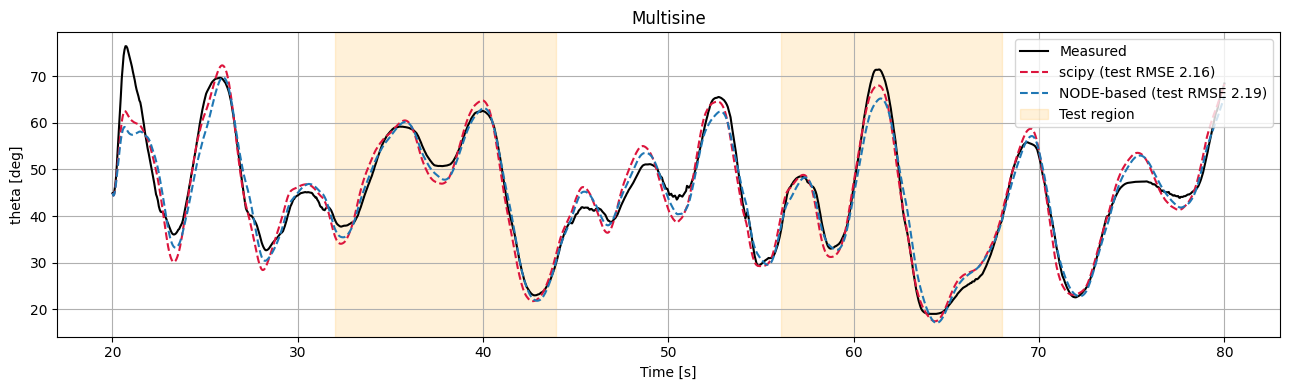

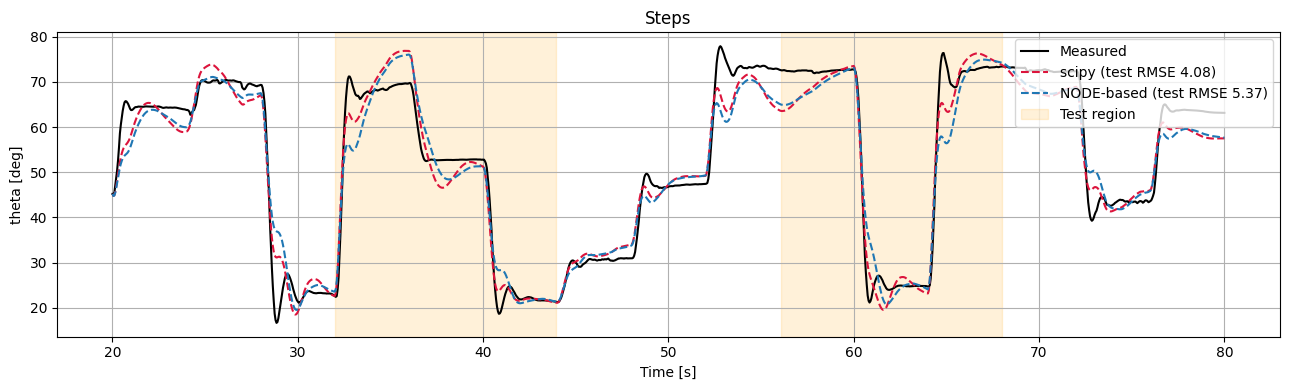

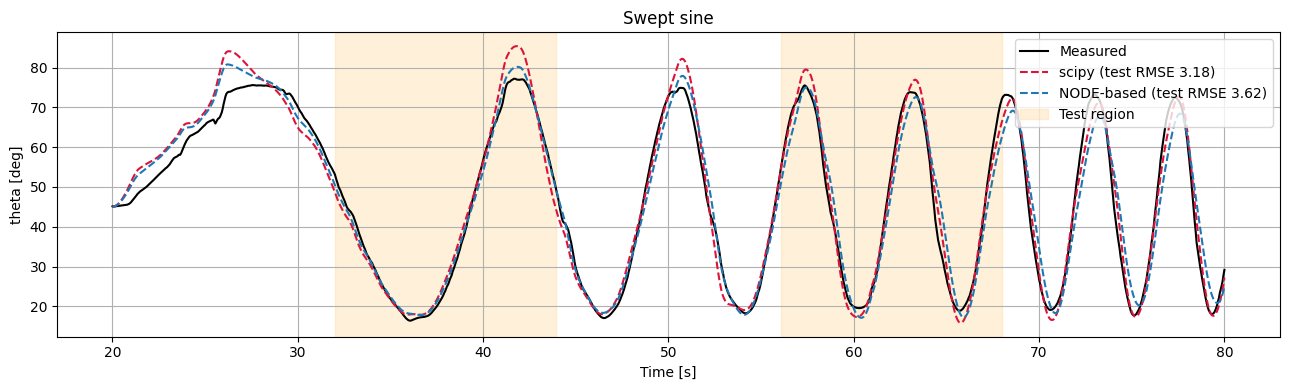


Free-run test RMSE [deg]      scipy / NODE-based
  multisine :   2.160 /   2.191
  steps     :   4.079 /   5.372
  swept     :   3.178 /   3.617


In [8]:
def free_run_deg(d, p):
    pred = rk4_rollout(np.array([d['th'][0]]), np.array([d['thd'][0]]), d['u'][None, :], p)[0]
    return pred / d2r

def plot_full(name, title):
    d = data[name]; t = d['t']; meas = d['theta_deg']; m = test_mask[name]
    ps = free_run_deg(d, p_scipy); pt = free_run_deg(d, p_torch)
    rmse_s = np.sqrt(np.mean((ps[m] - meas[m]) ** 2))
    rmse_t = np.sqrt(np.mean((pt[m] - meas[m]) ** 2))
    plt.figure(figsize=(13, 4))
    plt.plot(t, meas, 'k', label='Measured')
    plt.plot(t, ps, '--', color='crimson', label=f'scipy (test RMSE {rmse_s:.2f})')
    plt.plot(t, pt, '--', color='tab:blue', label=f'NODE-based (test RMSE {rmse_t:.2f})')
    _, te = train_test_blocks(len(meas))
    for j, (a, b) in enumerate(te):
        plt.axvspan(t[a], t[b-1], color='orange', alpha=0.15,
                    label='Test region' if j == 0 else None)
    plt.xlabel('Time [s]'); plt.ylabel('theta [deg]'); plt.title(title)
    plt.legend(loc='upper right'); plt.grid(True); plt.tight_layout(); plt.show()
    return rmse_s, rmse_t

rm = plot_full('multiseno',  'Multisine')
rs_ = plot_full('degraus',   'Steps')
rw = plot_full('swept_sine', 'Swept sine')

print('\nFree-run test RMSE [deg]      scipy / NODE-based')
print(f'  multisine : {rm[0]:7.3f} / {rm[1]:7.3f}')
print(f'  steps     : {rs_[0]:7.3f} / {rs_[1]:7.3f}')
print(f'  swept     : {rw[0]:7.3f} / {rw[1]:7.3f}')
